In [9]:
import pandas as pd

# Lectura de los datasets
recorridos = pd.read_csv("recorridos-realizados-2024.csv")
usuarios = pd.read_csv("usuarios_ecobici_2024.csv")

# Verificación rápida
print("Recorridos:", recorridos.shape)
print("Usuarios:", usuarios.shape)


Recorridos: (3560404, 17)
Usuarios: (197079, 5)


In [35]:
recorridos.head(200)

,id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,genero
0,24496816,17,2024-12-31 08:18:58,202,001 - FACULTAD DE DERECHO,Av. Pres. Figueroa Alcorta 2120,-58.390602,-34.583749,2024-12-31 08:19:15,202,001 - FACULTAD DE DERECHO,Av. Pres. Figueroa Alcorta 2120,-58.390602,-34.583749,1166678.0,FIT,FEMALE
1,24492524,2,2024-12-30 19:21:45,251,388 - Plaza Jose C Paz,Dr. Prof. Pedro Chutro 2881,-58.402483,-34.641728,2024-12-30 19:21:47,41,041 - PARQUE PATRICIOS II,Av Caseros 3015,-58.405888,-34.637123,1133415.0,FIT,FEMALE
2,24493951,0,2024-12-30 21:08:03,418,345 - Plaza Mafalda,Conde & Concepción Arenal,-58.444580,-34.580938,NaN,418,345 - Plaza Mafalda,Conde & Concepción Arenal,-58.444580,-34.580938,1158360.0,ICONIC,FEMALE
3,24494848,6575,2024-12-30 23:22:17,177,177 -PLANETARIO,Av. Belisario Roldán y Av. Sarmiento,-58.411598,-34.571079,2024-12-31 01:11:52,336,207 - PLAZA ARENALES,Nueva York 3949,-58.511146,-34.599731,1224331.0,FIT,FEMALE
4,24495039,3162,2024-12-30 23:52:00,359,250 - Fleni,2292 Montañeses,-58.450479,-34.555602,2024-12-31 00:44:42,85,085 - AGUERO,"Aguero & Mansilla, Lucio Norberto, General",-58.409178,-34.594806,1280053.0,ICONIC,FEMALE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,24494541,501,2024-12-30 22:26:54,96,096 - Carlos Gardel,3302 Guardia Vieja & Aguero,-58.411659,-34.602781,2024-12-30 22:35:15,169,169 - FACULTAD DE PSICOLOGIA,Av. Hipólito Yrigoyen 3417,-58.414971,-34.613071,1256083.0,FIT,FEMALE
196,24494506,1128,2024-12-30 22:18:50,370,305 - Plaza Martin Rodriguez,3016 Pareja,-58.500336,-34.590964,2024-12-30 22:37:38,368,378 - AGRONOMIA,Enzo Brdabehere 2897,-58.481323,-34.599938,935628.0,ICONIC,FEMALE
197,24494485,1188,2024-12-30 22:15:13,202,001 - FACULTAD DE DERECHO,Av. Pres. Figueroa Alcorta 2120,-58.390602,-34.583749,2024-12-30 22:35:01,239,391 - Plaza República de Ecuador,Av. Pres. Figueroa Alcorta 5201,-58.420621,-34.565337,687496.0,FIT,FEMALE
198,24494536,397,2024-12-30 22:25:30,161,161 - Humahuaca,3912 Humahuaca,-58.419676,-34.602078,2024-12-30 22:32:07,96,096 - Carlos Gardel,3302 Guardia Vieja & Aguero,-58.411659,-34.602781,52070.0,ICONIC,MALE


In [40]:
# Conteo de duplicados por fila completa en `recorridos`
dup_mask = recorridos.duplicated(keep='first')
dup_count = int(dup_mask.sum())
total = len(recorridos)

print(f"Duplicados (filas completas): {dup_count:,} de {total:,} ({dup_count/total*100:.6f}%)")

# Mostrar algunas filas que participan en duplicados (todas las ocurrencias), si existen
if dup_count:
    display(recorridos[recorridos.duplicated(keep=False)].head(10))

Duplicados (filas completas): 1,121 de 3,560,404 (0.031485%)


,id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,genero
5845,22425357,1119,2024-07-23 12:30:30,104,104 - Federico Lacroze,Av. Guzman 1100 & Av. Corrientes,-58.455212,-34.587617,2024-07-23 12:49:09,402,-- CDO Chacarita -- (Temporal),3209 Av. Francisco Beiro,-58.498542,-34.597612,1039158.0,FIT,MALE
5846,22425357,1119,2024-07-23 12:30:30,104,104 - Federico Lacroze,Av. Guzman 1100 & Av. Corrientes,-58.455212,-34.587617,2024-07-23 12:49:09,402,-- CDO Chacarita -- (Temporal),3209 Av. Francisco Beiro,-58.498542,-34.597612,1039158.0,FIT,MALE
7500,23489300,379,2024-10-18 09:33:58,6,006 - Parque Lezama,"Avenida Martin Garcia, 295",-58.369758,-34.628526,2024-10-18 09:40:17,433,273 - Plazoleta Colombia,1619 Brandsen,-58.373726,-34.637697,1161470.0,FIT,FEMALE
7501,23489300,379,2024-10-18 09:33:58,6,006 - Parque Lezama,"Avenida Martin Garcia, 295",-58.369758,-34.628526,2024-10-18 09:40:17,433,273 - Plazoleta Colombia,1619 Brandsen,-58.373726,-34.637697,1161470.0,FIT,FEMALE
7721,23478429,634,2024-10-17 16:36:36,433,273 - Plazoleta Colombia,1619 Brandsen,-58.373726,-34.637697,2024-10-17 16:47:10,172,172 - BRASIL,BRASIL&DEFENSA,-58.371082,-34.625426,1161470.0,ICONIC,FEMALE
7722,23478429,634,2024-10-17 16:36:36,433,273 - Plazoleta Colombia,1619 Brandsen,-58.373726,-34.637697,2024-10-17 16:47:10,172,172 - BRASIL,BRASIL&DEFENSA,-58.371082,-34.625426,1161470.0,ICONIC,FEMALE
9959,23452524,2312,2024-10-16 09:03:12,117,117 - HUMBERTO 1°,Av. Carlos Calvo 513,-58.373159,-34.619553,2024-10-16 09:41:44,164,164 - FACULTAD DE INGENIERIA,AV. PASEO COLÓN 811,-58.369898,-34.617301,1161470.0,FIT,FEMALE
9960,23452524,2312,2024-10-16 09:03:12,117,117 - HUMBERTO 1°,Av. Carlos Calvo 513,-58.373159,-34.619553,2024-10-16 09:41:44,164,164 - FACULTAD DE INGENIERIA,AV. PASEO COLÓN 811,-58.369898,-34.617301,1161470.0,FIT,FEMALE
30311,24501606,975,2024-12-31 17:28:52,433,273 - Plazoleta Colombia,1619 Brandsen,-58.373726,-34.637697,2024-12-31 17:45:07,117,117 - HUMBERTO 1°,Av. Carlos Calvo 513,-58.373159,-34.619553,1161470.0,ICONIC,FEMALE
30312,24501606,975,2024-12-31 17:28:52,433,273 - Plazoleta Colombia,1619 Brandsen,-58.373726,-34.637697,2024-12-31 17:45:07,117,117 - HUMBERTO 1°,Av. Carlos Calvo 513,-58.373159,-34.619553,1161470.0,ICONIC,FEMALE


In [39]:
# Conteo de duplicados (filas completas y por columnas identificadoras cuando existan)
dfs = {
    'recorridos': recorridos,
    'recorridos2010': recorridos2010,
    'usuarios': usuarios,
    'biclicletero': biclicletero,
    'biclicletero_new': biclicletero_new,
    'biclicletero_old': biclicletero_old
}

id_candidates = ['id_recorrido', 'id_usuario', 'id', 'id_estacion', 'id_estacion_origen', 'numero_de_estacion']

for name, df in dfs.items():
    print(f"\n== {name} == ")
    total = len(df)
    full_dups = df.duplicated(keep='first').sum()
    print(f"Filas totales: {total:,}")
    print(f"Duplicados (filas completas): {full_dups:,} ({full_dups/total*100 if total else 0:.4f}%)")
    # Mostrar primeras filas duplicadas (si existen), pero limitar para evitar imprimir demasiado
    if full_dups:
        print("Ejemplo (primeras 5 filas que participan en duplicados completos):")
        display(df[df.duplicated(keep=False)].head(5))
    # Buscar duplicados por columnas tipo id si existen en el df
    found = False
    for col in id_candidates:
        if col in df.columns:
            found = True
            dup_by_col = df[col].duplicated(keep='first').sum()
            unique_vals = df[col].nunique(dropna=False)
            print(f"Columna '{col}': valores únicos={unique_vals:,}, duplicados en columna={dup_by_col:,}")
            # top valores repetidos (>1), mostrar hasta 10
            vc = df[col].value_counts()
            repeated = vc[vc > 1].head(10)
            if not repeated.empty:
                print(f"  Top valores repetidos en '{col}':")
                print(repeated)
    if not found:
        print("No se encontraron columnas identificadoras candidatas en este DataFrame.")

# Conteo de duplicados por columnas relevantes comunes en recorridos
# columnas que suelen identificar un viaje compuesto
if 'recorridos' in dfs:
    cols_to_check = ['fecha_origen_recorrido', 'id_estacion_origen', 'id_estacion_destino', 'id_usuario', 'duracion_recorrido']
    existing = [c for c in cols_to_check if c in recorridos.columns]
    if existing:
        subset_dups = recorridos.duplicated(subset=existing, keep='first').sum()
        print(f"\nRecorridos: duplicados según subset {existing}: {subset_dups:,} ({subset_dups/len(recorridos)*100:.4f}%)")


== recorridos == 
Filas totales: 3,560,404
Duplicados (filas completas): 1,121 (0.0315%)
Ejemplo (primeras 5 filas que participan en duplicados completos):


,id_recorrido,duracion_recorrido,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,direccion_estacion_origen,long_estacion_origen,lat_estacion_origen,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,direccion_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario,modelo_bicicleta,genero
5845,22425357,1119,2024-07-23 12:30:30,104,104 - Federico Lacroze,Av. Guzman 1100 & Av. Corrientes,-58.455212,-34.587617,2024-07-23 12:49:09,402,-- CDO Chacarita -- (Temporal),3209 Av. Francisco Beiro,-58.498542,-34.597612,1039158.0,FIT,MALE
5846,22425357,1119,2024-07-23 12:30:30,104,104 - Federico Lacroze,Av. Guzman 1100 & Av. Corrientes,-58.455212,-34.587617,2024-07-23 12:49:09,402,-- CDO Chacarita -- (Temporal),3209 Av. Francisco Beiro,-58.498542,-34.597612,1039158.0,FIT,MALE
7500,23489300,379,2024-10-18 09:33:58,6,006 - Parque Lezama,"Avenida Martin Garcia, 295",-58.369758,-34.628526,2024-10-18 09:40:17,433,273 - Plazoleta Colombia,1619 Brandsen,-58.373726,-34.637697,1161470.0,FIT,FEMALE
7501,23489300,379,2024-10-18 09:33:58,6,006 - Parque Lezama,"Avenida Martin Garcia, 295",-58.369758,-34.628526,2024-10-18 09:40:17,433,273 - Plazoleta Colombia,1619 Brandsen,-58.373726,-34.637697,1161470.0,FIT,FEMALE
7721,23478429,634,2024-10-17 16:36:36,433,273 - Plazoleta Colombia,1619 Brandsen,-58.373726,-34.637697,2024-10-17 16:47:10,172,172 - BRASIL,BRASIL&DEFENSA,-58.371082,-34.625426,1161470.0,ICONIC,FEMALE


Columna 'id_recorrido': valores únicos=3,559,283, duplicados en columna=1,121
  Top valores repetidos en 'id_recorrido':
id_recorrido
24088684    2
24140372    2
24148163    2
24354065    2
22333434    2
22328434    2
24277064    2
22947270    2
24256164    2
22093244    2
Name: count, dtype: int64
Columna 'id_usuario': valores únicos=262,673, duplicados en columna=3,297,731
  Top valores repetidos en 'id_usuario':
id_usuario
844251.0    8488
55590.0     1423
11188.0     1303
96905.0     1280
668737.0    1270
96713.0     1196
41176.0     1191
3820.0      1049
12434.0     1012
79281.0      990
Name: count, dtype: int64
Columna 'id_estacion_origen': valores únicos=395, duplicados en columna=3,560,009
  Top valores repetidos en 'id_estacion_origen':
id_estacion_origen
175    38284
14     37594
516    37201
5      34547
202    30955
8      30403
130    29311
152    28225
289    27729
131    26968
Name: count, dtype: int64

== recorridos2010 == 
Filas totales: 3,158
Duplicados (filas comple

,periodo,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,long_estacion_origen,lat_estacion_origen,domicilio_estacion_origen,duracion_recorrido,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,long_estacion_destino,lat_estacion_destino,domicilio_estacion_destino
54,2010,30/12/2010 16:56,2,Retiro,-58.374822,-34.592589,Av. Dr.Jose Ramos Mejia y Del Libertador Av,23.0,30/12/2010 17:19,3,Aduana,-58.368918,-34.611242,Av. Ing.Huergo y Av. Belgrano
55,2010,30/12/2010 16:56,2,Retiro,-58.374822,-34.592589,Av. Dr.Jose Ramos Mejia y Del Libertador Av,23.0,30/12/2010 17:19,3,Aduana,-58.368918,-34.611242,Av. Ing.Huergo y Av. Belgrano
90,2010,30/12/2010 14:49,3,Aduana,-58.368918,-34.611242,Av. Ing.Huergo y Av. Belgrano,84.0,30/12/2010 16:13,3,Aduana,-58.368918,-34.611242,Av. Ing.Huergo y Av. Belgrano
91,2010,30/12/2010 14:49,3,Aduana,-58.368918,-34.611242,Av. Ing.Huergo y Av. Belgrano,84.0,30/12/2010 16:13,3,Aduana,-58.368918,-34.611242,Av. Ing.Huergo y Av. Belgrano
638,2010,27/12/2010 13:15,3,Aduana,-58.368918,-34.611242,Av. Ing.Huergo y Av. Belgrano,31.0,27/12/2010 13:46,3,Aduana,-58.368918,-34.611242,Av. Ing.Huergo y Av. Belgrano


Columna 'id_estacion_origen': valores únicos=4, duplicados en columna=3,154
  Top valores repetidos en 'id_estacion_origen':
id_estacion_origen
3    1029
2     975
1     648
4     506
Name: count, dtype: int64

== usuarios == 
Filas totales: 197,079
Duplicados (filas completas): 0 (0.0000%)
Columna 'id_usuario': valores únicos=197,079, duplicados en columna=0

== biclicletero == 
Filas totales: 407
Duplicados (filas completas): 0 (0.0000%)
Columna 'id': valores únicos=407, duplicados en columna=0
Columna 'numero_de_estacion': valores únicos=398, duplicados en columna=9
  Top valores repetidos en 'numero_de_estacion':
numero_de_estacion
307    2
48     2
30     2
142    2
230    2
389    2
363    2
95     2
239    2
Name: count, dtype: int64

== biclicletero_new == 
Filas totales: 405
Duplicados (filas completas): 0 (0.0000%)
Columna 'id': valores únicos=405, duplicados en columna=0
Columna 'numero_de_estacion': valores únicos=394, duplicados en columna=11
  Top valores repetidos en 'nu

In [ ]:
## Count distinct values for each column
distinct_counts = {
    'id_estacion_origen': recorridos['id_estacion_origen'].nunique(),
    'nombre_estacion_origen': recorridos['nombre_estacion_origen'].nunique(),
    'direccion_estacion_origen': recorridos['direccion_estacion_origen'].nunique()
}

# Create a DataFrame for better visualization
result_df = pd.DataFrame.from_dict(distinct_counts, orient='index', columns=['Distinct Count'])
display(result_df)

# Optional: Show some examples of the values
print("\nSample of unique values from each column:")
for col in distinct_counts.keys():
    print(f"\n{col}:")
    print(recorridos[col].unique()[:5])  # Show first 5 unique values

,Distinct Count
id_estacion_origen,395
nombre_estacion_origen,395
direccion_estacion_origen,393



Sample of unique values from each column:

id_estacion_origen:
[202 251 418 177 359]

nombre_estacion_origen:
['001 - FACULTAD DE DERECHO' '388 - Plaza Jose C Paz'
 '345 - Plaza Mafalda' '177 -PLANETARIO' '250 - Fleni']

direccion_estacion_origen:
['Av. Pres. Figueroa Alcorta 2120' 'Dr. Prof. Pedro Chutro 2881'
 'Conde & Concepción Arenal' 'Av. Belisario Roldán y Av. Sarmiento'
 '2292 Montañeses']


In [36]:
import pandas as _pd

# Buscar valores que representen nulos pero no sean np.nan explícito (ej. "None", "null", "N/A", "", "-")
placeholders = {
    "none", "null", "n/a", "na", "sin dato", "s/d", "-", "", " ", "nd", "no disponible"
}

rows = []
for col in recorridos.columns:
    s = recorridos[col]
    # comprobación explícita de None (aunque pandas suele convertirlo a NaN)
    none_mask = s.apply(lambda x: x is None)
    # detectar placeholders en forma de string, excluyendo los verdaderos NaN/pd.NaT
    lowered = s.astype(str).str.strip().str.lower()
    placeholder_mask = (~s.isnull()) & (lowered.isin(placeholders))
    count_none = int(none_mask.sum())
    count_placeholders = int(placeholder_mask.sum())
    if count_none + count_placeholders > 0:
        examples_idx = list(recorridos.index[none_mask | placeholder_mask][:5])
        examples_vals = list((recorridos.loc[examples_idx, col].astype(str)).values)
        unique_found = sorted(set([v for v in lowered[placeholder_mask].unique() if v is not None]))
        rows.append({
            "column": col,
            "none_count": count_none,
            "placeholder_count": count_placeholders,
            "placeholders_found": unique_found,
            "example_indices": examples_idx,
            "example_values": examples_vals
        })

summary = _pd.DataFrame(rows)
if summary.empty:
    print("No se encontraron valores tipo 'None' o placeholders de nulos (diferentes de NaN) en recorridos.")
else:
    display(summary)
    # Mostrar algunas filas que contienen esos valores para inspección
    sample_idx = summary["example_indices"].explode().dropna().unique().tolist()
    if sample_idx:
        print("\nEjemplos de filas con esos valores (hasta 10):")
        display(recorridos.loc[sample_idx[:10], :])

No se encontraron valores tipo 'None' o placeholders de nulos (diferentes de NaN) en recorridos.


In [17]:
# Display null values count for each column in recorridos
recorridos.isnull().sum()

id_recorrido                      0
duracion_recorrido                0
fecha_origen_recorrido            0
id_estacion_origen                0
nombre_estacion_origen            0
direccion_estacion_origen         0
long_estacion_origen              0
lat_estacion_origen               0
fecha_destino_recorrido        3380
id_estacion_destino               0
nombre_estacion_destino           0
direccion_estacion_destino        0
long_estacion_destino             0
lat_estacion_destino              0
id_usuario                        0
modelo_bicicleta                  0
genero                        11946
dtype: int64

In [11]:
recorridos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3560404 entries, 0 to 3560403
Data columns (total 17 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   id_recorrido                int64  
 1   duracion_recorrido          int64  
 2   fecha_origen_recorrido      object 
 3   id_estacion_origen          int64  
 4   nombre_estacion_origen      object 
 5   direccion_estacion_origen   object 
 6   long_estacion_origen        float64
 7   lat_estacion_origen         float64
 8   fecha_destino_recorrido     object 
 9   id_estacion_destino         int64  
 10  nombre_estacion_destino     object 
 11  direccion_estacion_destino  object 
 12  long_estacion_destino       float64
 13  lat_estacion_destino        float64
 14  id_usuario                  float64
 15  modelo_bicicleta            object 
 16  genero                      object 
dtypes: float64(5), int64(4), object(8)
memory usage: 461.8+ MB


In [12]:
recorridos.describe()


,id_recorrido,duracion_recorrido,id_estacion_origen,long_estacion_origen,lat_estacion_origen,id_estacion_destino,long_estacion_destino,lat_estacion_destino,id_usuario
count,3.560404e+06,3.560404e+06,3.560404e+06,3.560404e+06,3.560404e+06,3.560404e+06,3.560404e+06,3.560404e+06,3.560404e+06
mean,2.234132e+07,1.274680e+03,2.355957e+02,-5.842302e+01,-3.459877e+01,2.371506e+02,-5.842318e+01,-3.459896e+01,7.908728e+05
std,1.257073e+06,9.582717e+03,1.657999e+02,3.830469e-02,2.441487e-02,1.657100e+02,3.848631e-02,2.477407e-02,3.881981e+05
min,2.018097e+07,0.000000e+00,2.000000e+00,-5.852710e+01,-3.468777e+01,2.000000e+00,-5.852710e+01,-3.468777e+01,2.400000e+01
25%,2.123866e+07,4.930000e+02,9.300000e+01,-5.844965e+01,-3.461635e+01,9.600000e+01,-5.844966e+01,-3.461649e+01,5.118240e+05
50%,2.235131e+07,8.810000e+02,1.990000e+02,-5.842095e+01,-3.460028e+01,2.000000e+02,-5.842095e+01,-3.460075e+01,9.131670e+05
75%,2.343700e+07,1.473000e+03,3.780000e+02,-5.839374e+01,-3.458255e+01,3.790000e+02,-5.839374e+01,-3.458234e+01,1.113537e+06
max,2.450328e+07,2.571165e+06,5.770000e+02,-5.835547e+01,-3.453669e+01,5.770000e+02,-5.835547e+01,-3.453669e+01,1.280599e+06


In [13]:
usuarios

,id_usuario,genero_usuario,edad_usuario,fecha_alta,hora_alta
0,1083579,OTHER,23,2024-01-01,01:59:02
1,1083608,OTHER,36,2024-01-01,02:55:46
2,1083612,OTHER,38,2024-01-01,03:13:15
3,1083616,FEMALE,21,2024-01-01,03:40:54
4,1083631,MALE,36,2024-01-01,05:02:35
...,...,...,...,...,...
197074,1153589,MALE,55,2024-05-08,18:17:14
197075,1086260,FEMALE,45,2024-01-04,15:49:00
197076,1255942,MALE,28,2024-11-21,16:37:50
197077,1158942,MALE,18,2024-05-22,13:16:34


In [38]:
usuarios.isnull().sum()

id_usuario        0
genero_usuario    0
edad_usuario      0
fecha_alta        0
hora_alta         0
dtype: int64

In [21]:
result = usuarios[usuarios['id_usuario'] == 23764]
result

,id_usuario,genero_usuario,edad_usuario,fecha_alta,hora_alta


,count,percent
genero_usuario,,
MALE,88656,44.99
FEMALE,79310,40.24
OTHER,29113,14.77


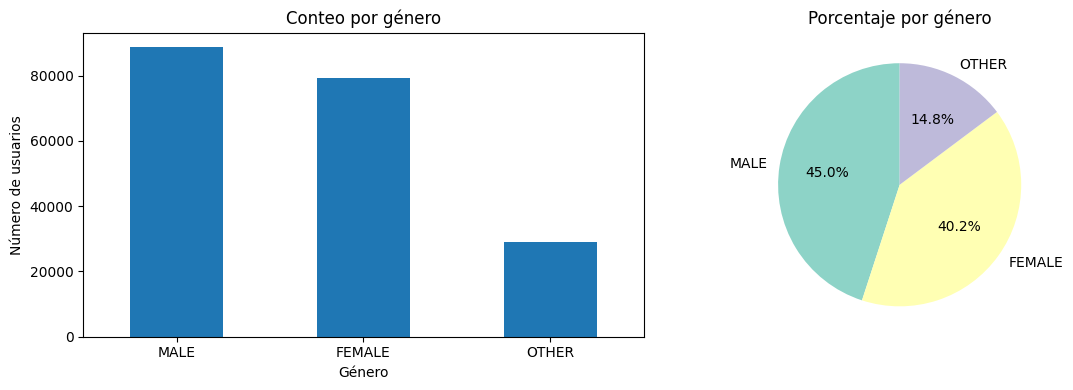

In [ ]:
c

,count,percent
genero,,
MALE,2148323,60.34
FEMALE,1134153,31.85
OTHER,265982,7.47
NaN,11946,0.34


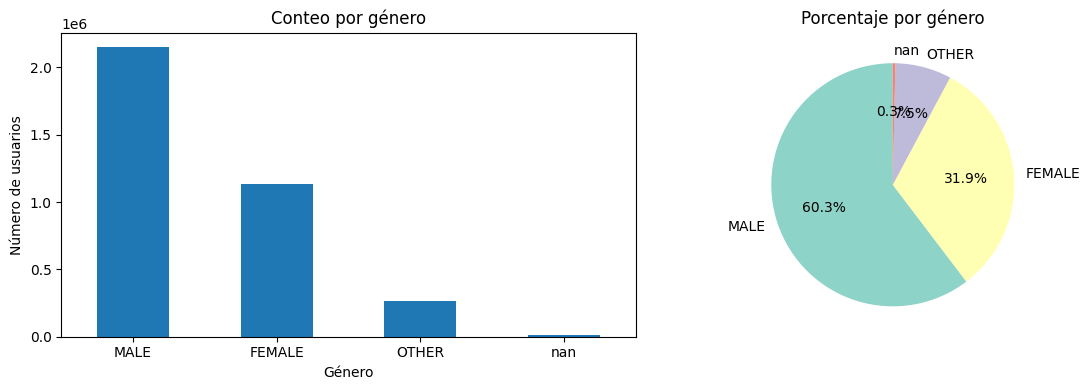

In [23]:
# Distribución de genero_usuario en usuarios
counts = recorridos['genero'].value_counts(dropna=False)
percent = recorridos['genero'].value_counts(normalize=True, dropna=False) * 100

display(pd.DataFrame({'count': counts, 'percent': percent.round(2)}))

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart de conteos
counts.plot(kind='bar', ax=ax[0], color='C0', rot=0)
ax[0].set_title('Conteo por género')
ax[0].set_ylabel('Número de usuarios')
ax[0].set_xlabel('Género')

# Pie chart de porcentajes
percent.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', ylabel='', startangle=90, colors=plt.cm.Set3.colors)
ax[1].set_title('Porcentaje por género')

plt.tight_layout()
plt.show()


,count,percent
modelo_bicicleta,,
FIT,2583213,72.55
ICONIC,977191,27.45


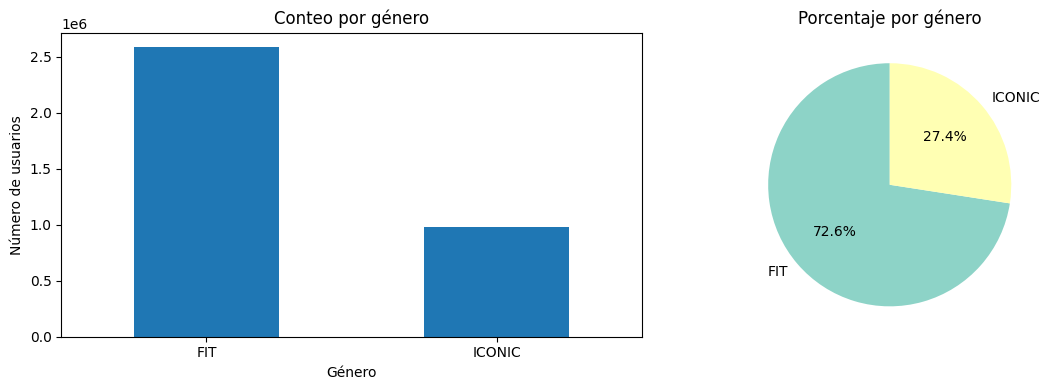

In [24]:
# Distribución de genero_usuario en usuarios
counts = recorridos['modelo_bicicleta'].value_counts(dropna=False)
percent = recorridos['modelo_bicicleta'].value_counts(normalize=True, dropna=False) * 100

display(pd.DataFrame({'count': counts, 'percent': percent.round(2)}))

import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart de conteos
counts.plot(kind='bar', ax=ax[0], color='C0', rot=0)
ax[0].set_title('Conteo por género')
ax[0].set_ylabel('Número de usuarios')
ax[0].set_xlabel('Género')

# Pie chart de porcentajes
percent.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', ylabel='', startangle=90, colors=plt.cm.Set3.colors)
ax[1].set_title('Porcentaje por género')

plt.tight_layout()
plt.show()

In [14]:
usuarios.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197079 entries, 0 to 197078
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   id_usuario      197079 non-null  int64 
 1   genero_usuario  197079 non-null  object
 2   edad_usuario    197079 non-null  int64 
 3   fecha_alta      197079 non-null  object
 4   hora_alta       197079 non-null  object
dtypes: int64(2), object(3)
memory usage: 7.5+ MB


In [15]:
recorridos2010 = pd.read_csv("recorridos-realizados-2010.csv")

In [16]:
recorridos2010

,periodo,fecha_origen_recorrido,id_estacion_origen,nombre_estacion_origen,long_estacion_origen,lat_estacion_origen,domicilio_estacion_origen,duracion_recorrido,fecha_destino_recorrido,id_estacion_destino,nombre_estacion_destino,long_estacion_destino,lat_estacion_destino,domicilio_estacion_destino
0,2010,30/12/2010 19:39,1,Facultad de Derecho,-58.392452,-34.583133,Av. Pres.Figueroa Alcorta y Juan A.Bibiloni,7.0,30/12/2010 19:46,2,Retiro,-58.374822,-34.592589,Av. Dr.Jose Ramos Mejia y Del Libertador Av
1,2010,30/12/2010 19:34,3,Aduana,-58.368918,-34.611242,Av. Ing.Huergo y Av. Belgrano,13.0,30/12/2010 19:47,2,Retiro,-58.374822,-34.592589,Av. Dr.Jose Ramos Mejia y Del Libertador Av
2,2010,30/12/2010 19:10,4,Plaza Roma,-58.368950,-34.601721,Lavalle y Bouchard,7.0,30/12/2010 19:17,2,Retiro,-58.374822,-34.592589,Av. Dr.Jose Ramos Mejia y Del Libertador Av
3,2010,30/12/2010 19:03,1,Facultad de Derecho,-58.392452,-34.583133,Av. Pres.Figueroa Alcorta y Juan A.Bibiloni,26.0,30/12/2010 19:29,3,Aduana,-58.368918,-34.611242,Av. Ing.Huergo y Av. Belgrano
4,2010,30/12/2010 19:02,3,Aduana,-58.368918,-34.611242,Av. Ing.Huergo y Av. Belgrano,11.0,30/12/2010 19:13,2,Retiro,-58.374822,-34.592589,Av. Dr.Jose Ramos Mejia y Del Libertador Av
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3153,2010,01/12/2010 9:04,2,Retiro,-58.374822,-34.592589,Av. Dr.Jose Ramos Mejia y Del Libertador Av,15.0,01/12/2010 9:19,3,Aduana,-58.368918,-34.611242,Av. Ing.Huergo y Av. Belgrano
3154,2010,01/12/2010 7:35,2,Retiro,-58.374822,-34.592589,Av. Dr.Jose Ramos Mejia y Del Libertador Av,2.0,01/12/2010 7:37,2,Retiro,-58.374822,-34.592589,Av. Dr.Jose Ramos Mejia y Del Libertador Av
3155,2010,27/12/2010 18:04,3,Aduana,-58.368918,-34.611242,Av. Ing.Huergo y Av. Belgrano,NaN,28/12/2010 11:24,3,Aduana,-58.368918,-34.611242,Av. Ing.Huergo y Av. Belgrano
3156,2010,22/12/2010 19:17,4,Plaza Roma,-58.368950,-34.601721,Lavalle y Bouchard,NaN,23/12/2010 8:40,1,Facultad de Derecho,-58.392452,-34.583133,Av. Pres.Figueroa Alcorta y Juan A.Bibiloni


In [25]:
biclicletero = pd.read_csv("nuevas-estaciones-bicicletas-publicas.csv")

biclicletero

,id,numero_de_estacion,nombre,direccion,barrio,comuna,emplazamiento,latitud,longitud
0,240,239,VIDAL,Av. Cramer 2900,NaN,NaN,NaN,-34.558137,-58.467259
1,95,95,ESMERALDA,Av. Antártida Argentina & Cecilia Grierson,NaN,NaN,NaN,-34.595653,-58.369162
2,30,30,PEÑA,Peña & Azcuenaga,NaN,NaN,NaN,-34.590821,-58.397370
3,121,121,YATAY,925 Yatay& Humahuaca,NaN,NaN,NaN,-34.601173,-58.428509
4,473,216,EMILIO LAMARCA,EMILIO LAMARCA 2066,NaN,NaN,NaN,-34.613403,-58.493358
...,...,...,...,...,...,...,...,...,...
402,131,131,HOSPITAL DE CLÍNICAS,"Uriburu Jose E., Pres. & Paraguay",NaN,NaN,NaN,-34.598404,-58.399016
403,382,204,BIARRITZ,Biarritz 2403,NaN,NaN,NaN,-34.605431,-58.477255
404,501,20,GRECIA,Grecia 3290,NaN,NaN,NaN,-34.549249,-58.461941
405,175,147,CONSTITUCIÓN,Avenida Juan de Garay 1050,NaN,NaN,NaN,-34.626851,-58.380707


In [27]:
print(biclicletero[biclicletero['id'] == 202])

      id  numero_de_estacion               nombre  \
205  202                   1  FACULTAD DE DERECHO   

                           direccion  barrio  comuna  emplazamiento  \
205  Av. Pres. Figueroa Alcorta 2120     NaN     NaN            NaN   

       latitud   longitud  
205 -34.583749 -58.390602  


In [31]:
biclicletero_old = pd.read_csv("estaciones_sistema_viejo.csv")
biclicletero_old 

,id_estacion,nombre_estacion,long_estacion,lat_estacion,domicilio_estacion,tipo_estacion,observaciones,horario_estacion
0,1.0,Facultad de Derecho,-58.392452,-34.583133,Av. Pres.Figueroa Alcorta y Juan A.Bibiloni,AUTOMÁTICA,Abril 2015 (pasó de ser Manual a Automática),Estación automática: disponibilidad las 24 horas
1,2.0,Retiro,-58.374822,-34.592589,Av. Dr.Jose Ramos Mejia y Del Libertador Av,AUTOMÁTICA,Abril 2015 (pasó de ser Manual a Automática),Estación automática: disponibilidad las 24 horas
2,3.0,Aduana,-58.368918,-34.611242,Av. Ing.Huergo y Av. Belgrano,AUTOMÁTICA,Abril 2015 (pasó de ser Manual a Automática),Estación automática: disponibilidad las 24 horas
3,4.0,Plaza Roma,-58.368950,-34.601721,Lavalle y Bouchard,AUTOMÁTICA,Abril 2015 (pasó de ser Manual a Automática),Estación automática: disponibilidad las 24 horas
4,5.0,Plaza Italia,-58.420997,-34.580127,Av. Santa Fe y Av. Sarmiento,AUTOMÁTICA,Abril 2015 (pasó de ser Manual a Automática),Estación automática: disponibilidad las 24 horas
...,...,...,...,...,...,...,...,...
199,200.0,Austria y French,-58.404361,-34.588191,Austria 2080 entre French y Juncal,AUTOMÁTICA,Septiembre 2017,Estación automática: disponibilidad las 24 horas
200,NaN,CMD,NaN,NaN,NaN,NaN,NaN,NaN
201,NaN,F. J. Santamaría de Oro,NaN,NaN,NaN,NaN,NaN,NaN
202,NaN,Fitz Roy y Gorriti,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print(biclicletero_old[biclicletero_old['id_estacion'] == 202.0])

Empty DataFrame
Columns: [id_estacion, nombre_estacion, long_estacion, lat_estacion, domicilio_estacion, tipo_estacion, observaciones, horario_estacion]
Index: []


In [32]:
biclicletero_new = pd.read_csv("badata_ecobici_estaciones_bicicletas_nuevo_sistema.csv")
biclicletero_new

,id,numero_de_estacion,nombre,direccion,barrio,comuna,emplazamiento,latitud,longitud
0,523,389,AV. ELCANO FIN DE VIDA,Av. Elcano 2998,NaN,NaN,NaN,-34.570812,-58.457868
1,485,230,PASEO DE LA COSTANERA II,Av. Costanera Rafael Obligado 5100,NaN,NaN,NaN,-34.553465,-58.421440
2,294,363,UDAONDO,AV. GUILLERMO UDAONDO 1290,NaN,NaN,NaN,-34.547131,-58.452466
3,119,119,EMILIO MITRE,"Pacheco De Melo, Jose Andres",NaN,NaN,NaN,-34.588561,-58.397329
4,466,333,PARQUE DE LA ESTACIÓN,Dr. Tomás Manuel de Anchorena 170,NaN,NaN,NaN,-34.608096,-58.411840
...,...,...,...,...,...,...,...,...,...
400,581,11,PLAZA BOEDO,Sánchez de Loria1009,NaN,NaN,NaN,-34.621952,-58.412366
401,482,376,PASEO DE LA COSTANERA,Av. Costanera Rafael Obligado 6200,NaN,NaN,NaN,-34.550468,-58.430024
402,500,235,COMUNA 13,Ibera 2377,NaN,NaN,NaN,-34.553212,-58.464224
403,548,51,PLAZA SUDAMERICA,Av. Piedrabuena 4901,NaN,NaN,NaN,-34.687767,-58.475178


In [34]:
print(biclicletero_new[biclicletero_new['id'] == 202])

      id  numero_de_estacion               nombre  \
331  202                   1  FACULTAD DE DERECHO   

                           direccion  barrio  comuna  emplazamiento  \
331  Av. Pres. Figueroa Alcorta 2120     NaN     NaN            NaN   

       latitud   longitud  
331 -34.583749 -58.390602  
